<a href="https://colab.research.google.com/github/shadenaalghannam/Data_Mining_Project_Group2/blob/main/Python%20Notebook/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing

In this phase, we analyze the dataset to understand its main characteristics and identify data quality issues. We then apply appropriate preprocessing techniques to prepare the data for further data mining tasks.

In [2]:
import pandas as pd
df = pd.read_csv("RAW_DataSet.csv")

#1. Data Analysis

## 1. Five-Number Summary

The five-number summary describes the distribution of the numerical attributes using the minimum, Q1, median, Q3, and maximum.

In [3]:
numerical_data = df.drop("Potability", axis=1)
five_number_summary = pd.DataFrame({
    "Minimum": numerical_data.min(),
    "Q1": numerical_data.quantile(0.25),
    "Median": numerical_data.quantile(0.50),
    "Q3": numerical_data.quantile(0.75),
    "Maximum": numerical_data.max()})
five_number_summary.round(2)

,Minimum,Q1,Median,Q3,Maximum
ph,0.00,6.09,7.04,8.06,14.00
Hardness,47.43,176.85,196.97,216.67,323.12
Solids,320.94,15666.69,20927.83,27332.76,61227.20
Chloramines,0.35,6.13,7.13,8.11,13.13
Sulfate,129.00,307.70,333.07,359.95,481.03
Conductivity,181.48,365.73,421.88,481.79,753.34
Organic_carbon,2.20,12.07,14.22,16.56,28.30
Trihalomethanes,0.74,55.84,66.62,77.34,124.00
Turbidity,1.45,3.44,3.96,4.50,6.74


### Interpretation

The summary shows variation across the water quality attributes, with noticeable differences between their ranges and quartiles.

### 2. Outlier Detection

Outliers are identified using the IQR method. Values below the lower bound or above the upper bound are considered potential outliers.

In [4]:
for column in numerical_data.columns:
    Q1 = numerical_data[column].quantile(0.25)
    Q3 = numerical_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    lower_outliers = numerical_data[column][
        numerical_data[column] < lower_bound ]

    upper_outliers = numerical_data[column][
        numerical_data[column] > upper_bound ]

    print("Attribute:", column)
    print("Lower Outliers:")
    if len(lower_outliers)== 0:
        print("None")
    else:
        print(lower_outliers.to_string(index=False))

    print("Upper Outliers:")
    if len(upper_outliers) ==0:
        print("None")
    else:
        print(upper_outliers.to_string(index=False))

    print("Total Number of Outliers:",
          len(lower_outliers) + len(upper_outliers))
    print("-"* 50)

Attribute: ph
Lower Outliers:
1.844538
2.612036
2.798549
1.757037
0.227499
0.989912
2.690831
2.569244
2.803563
2.558103
2.974429
2.538116
2.945469
2.376768
1.431782
0.975578
2.925174
3.102076
0.000000
2.128531
1.985383
Upper Outliers:
11.180284
11.180695
11.267828
13.175402
11.301794
11.898078
11.027880
11.244507
12.246928
11.534880
14.000000
11.568768
11.235426
11.069456
11.219135
11.907740
13.541240
13.349889
11.563169
11.496702
11.496859
11.621140
11.390543
11.449739
11.491011
Total Number of Outliers: 46
--------------------------------------------------
Attribute: Hardness
Lower Outliers:
100.457615
103.464759
116.299330
104.752425
112.299485
105.859264
112.820254
103.173587
 98.771644
 47.432000
 81.710895
113.831112
 77.459586
 94.091307
 73.492234
108.699077
106.380113
 97.280909
 98.452931
116.061950
107.383327
116.725122
113.504698
115.392979
117.057314
110.865788
108.916629
100.806520
107.341982
111.246412
116.905479
116.338278
113.024472
111.478582
113.175965
114.463900
111

###Interpretation:
The outlier values show that some water quality measurements are noticeably different from the majority of the data. These values may indicate unusual water samples and should be considered during preprocessing.

### 3. Boxplots

Boxplots provide another visual method for identifying potential outliers and showing the distribution of numerical attributes.

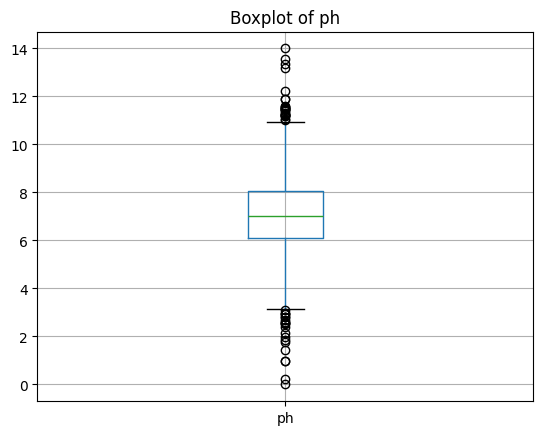

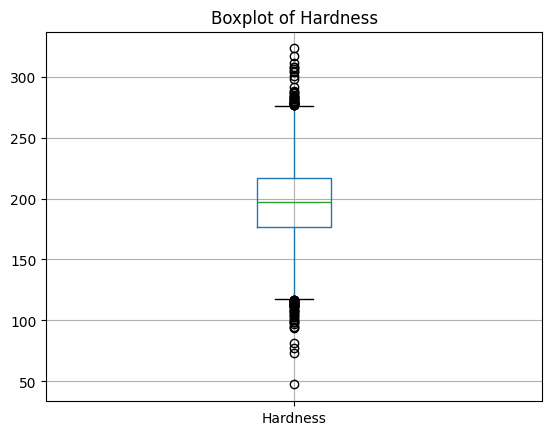

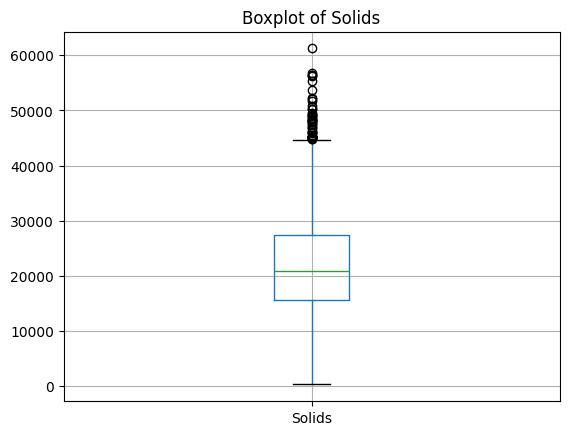

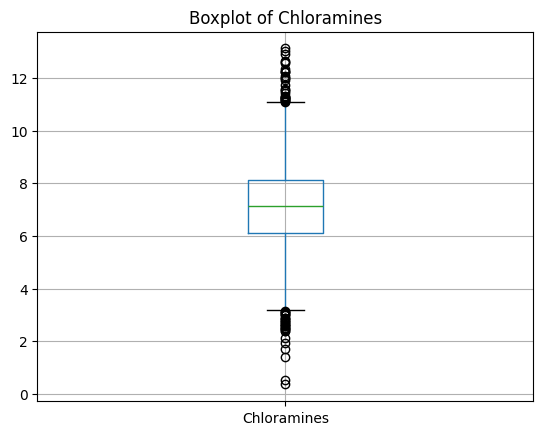

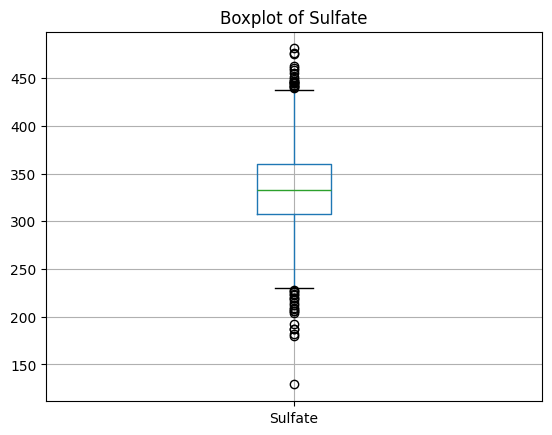

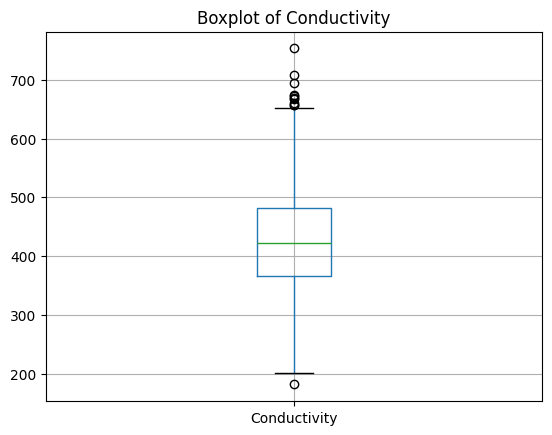

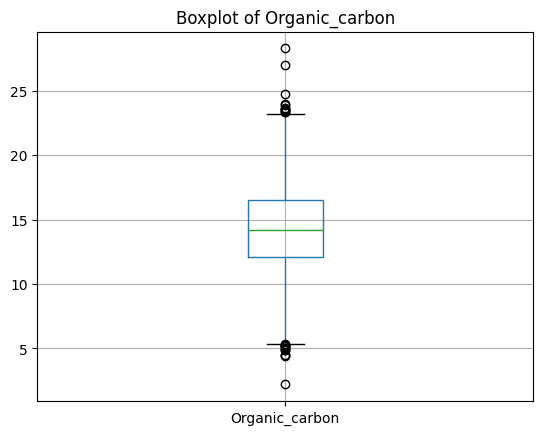

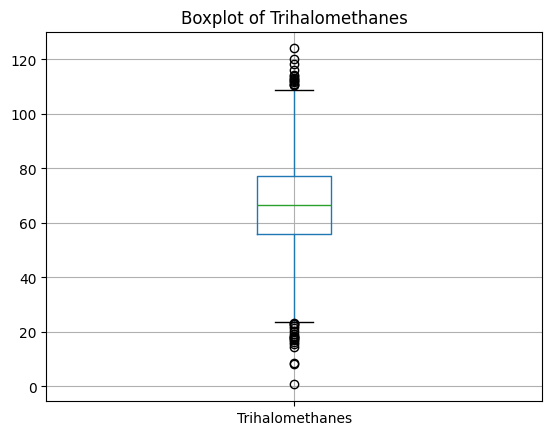

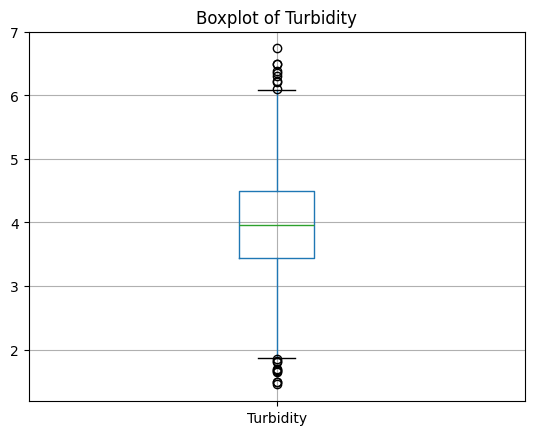

In [5]:
import matplotlib.pyplot as plt
for column in numerical_data.columns:
    numerical_data[[column]].boxplot()
    plt.title("Boxplot of "+column)
    plt.show()

###Interpretation:
The boxplots show that the numerical attributes have different distributions and contain some values that fall outside the main range of the data.

## 4. Scatter Plot

A scatter plot is used to visualize the relationship between two numerical attributes.

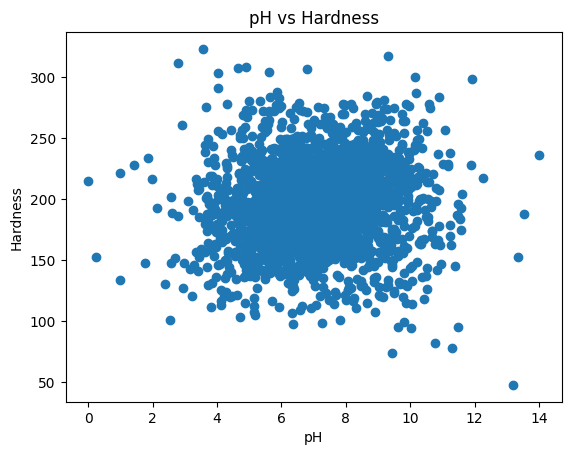

In [6]:
plt.scatter(numerical_data["ph"],numerical_data["Hardness"])
plt.xlabel("pH")
plt.ylabel("Hardness")
plt.title("pH vs Hardness")
plt.show()

###Interpretation:
The points are widely scattered with no clear strong relationship between pH and Hardness. Some values are also noticeably distant from the main group, indicating the presence of unusual observations that should be considered during preprocessing.

## 5. Histograms

Histograms are used to show the distribution of each numerical attribute.

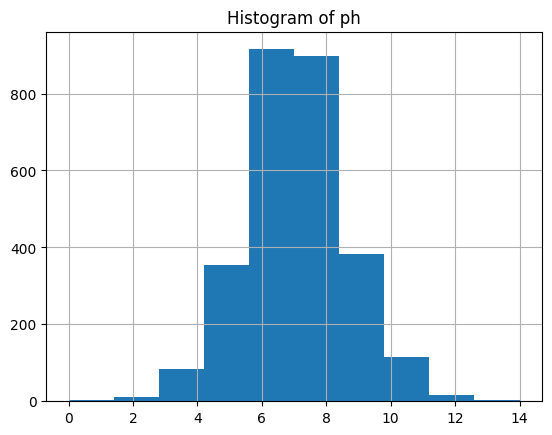

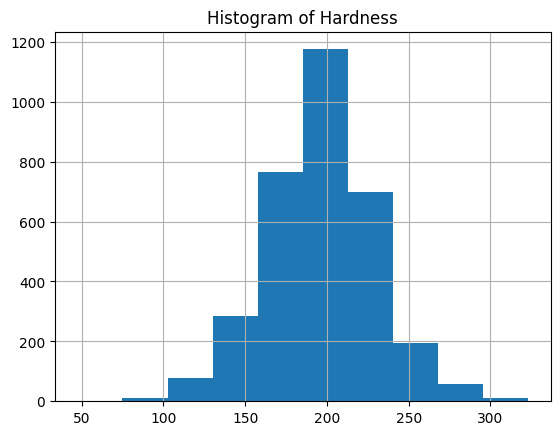

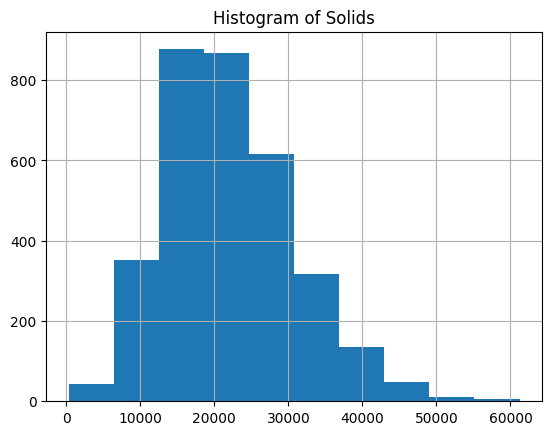

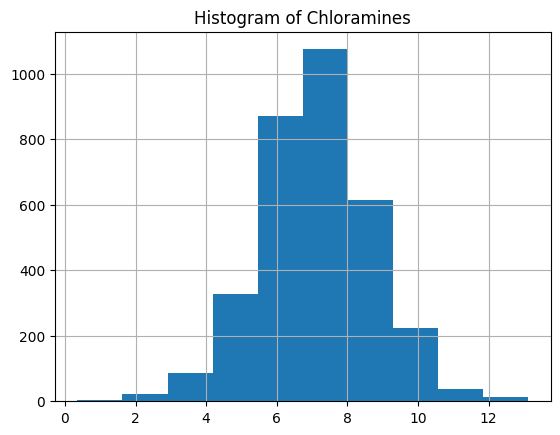

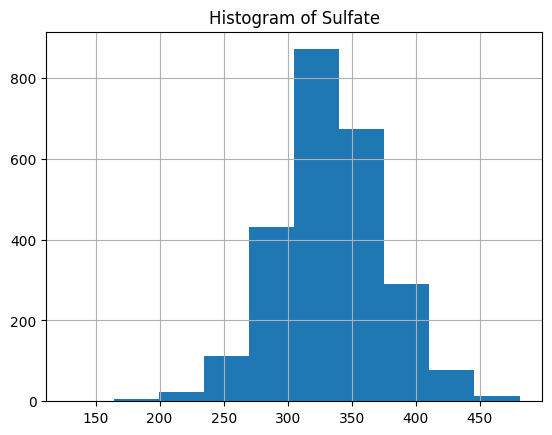

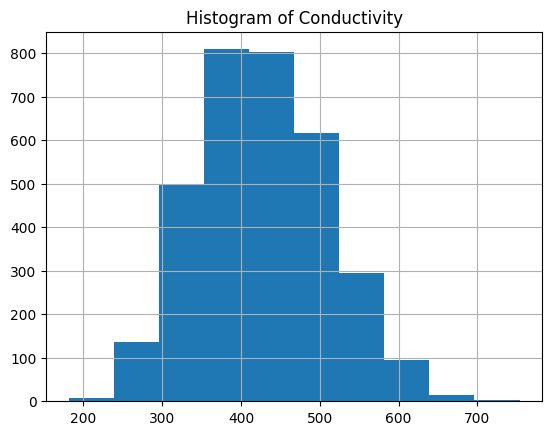

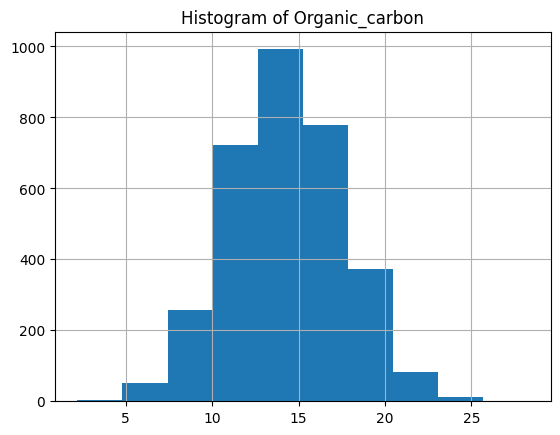

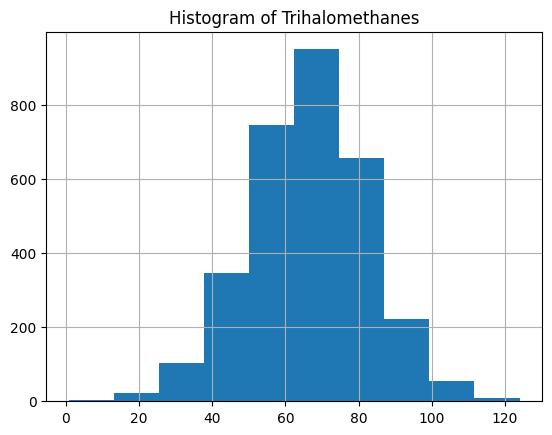

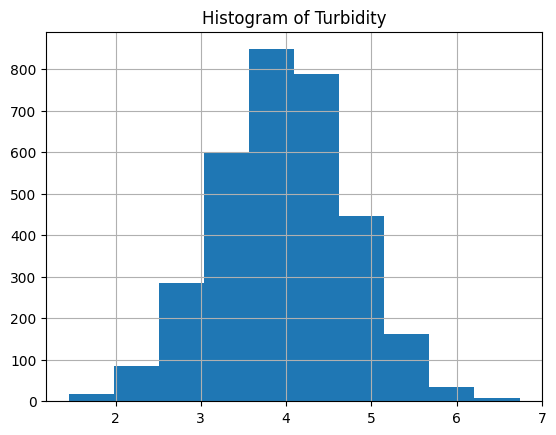

In [7]:
for column in numerical_data.columns:
    numerical_data[[column]].hist()
    plt.title("Histogram of " + column)
    plt.show()

### Interpretation:
The histograms show that most attributes have a roughly normal distribution, while Solids is skewed to the right. The attributes also have very different ranges of values, which shows that the data needs to be scaled during preprocessing.


## 6. Bar Plot

A bar plot is used to show the distribution of the class label (Potability), where 0 means not potable and 1 means potable.

Potability
0    1998
1    1278
Name: count, dtype: int64


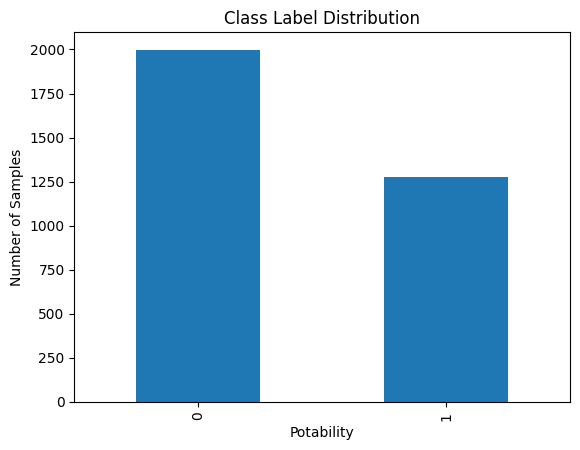

In [8]:
class_counts = df["Potability"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")
plt.xlabel("Potability")
plt.ylabel("Number of Samples")
plt.title("Class Label Distribution")
plt.show()

### Interpretation:
The bar plot of the class label distribution shows that the dataset contains more non-potable samples than potable samples, indicating some class imbalance. This imbalance should be considered when applying data mining techniques.

## 7. Missing Values

Missing values are checked for each attribute to find incomplete data.

In [9]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)})
missing_values

,Missing Count,Missing Percentage
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


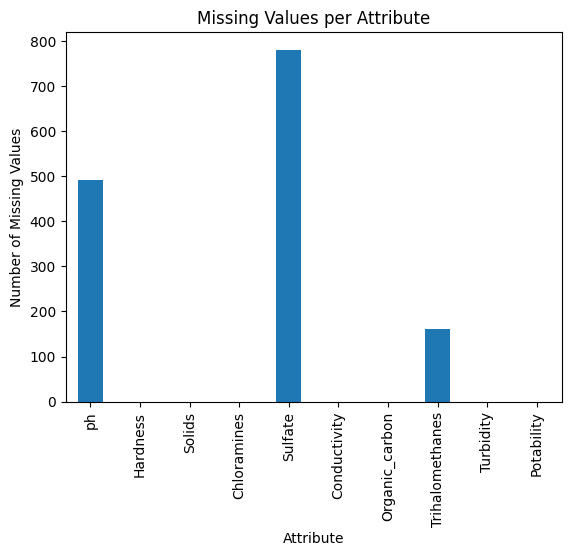

In [10]:
missing_values["Missing Count"].plot(kind="bar")
plt.xlabel("Attribute")
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Attribute")
plt.show()

### Interpretation:
The results show that three attributes contain missing values: Sulfate (781), ph (491) and Trihalomethanes (162). The other attributes have no missing values. These missing values should be handled during preprocessing, for example by filling them with the mean or median.

## 8. Statistical Summary

The statistical summary shows the count, mean, standard deviation, minimum, quartiles and maximum of each numerical attribute.

In [11]:
numerical_data.describe().round(2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74


### Interpretation:
The count values show that ph, Sulfate and Trihalomethanes have fewer values than the other attributes, which confirms that they contain missing values. The attributes also have very different means and standard deviations, which shows that the data should be scaled during preprocessing.

# 2. Data Preprocessing

## 1. Handling Missing Values
The dataset contains missing values in some numerical attributes. The missing values are replaced with the mean value of each numerical attribute.

In [12]:
print("Missing values before preprocessing:")
print(df.isna().sum())

column_means = df.mean(numeric_only=True)
df = df.fillna(column_means)

print("\nMissing values after preprocessing:")
print(df.isna().sum())

Missing values before preprocessing:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Missing values after preprocessing:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


The missing values were successfully replaced with the mean values of their corresponding numerical attributes. After preprocessing, the dataset contains no missing values.

## 2. Handling Outliers
The dataset contains outliers in some numerical attributes. The outliers are identified using the IQR method and treated by capping their values at the calculated lower and upper bounds.

In [13]:
numeric_columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                   'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) |
                  (df[column] > upper_bound)]

    print(column, ":", len(outliers), "outliers")

ph : 142 outliers
Hardness : 83 outliers
Solids : 47 outliers
Chloramines : 61 outliers
Sulfate : 264 outliers
Conductivity : 11 outliers
Organic_carbon : 25 outliers
Trihalomethanes : 54 outliers
Turbidity : 19 outliers


In [14]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) |
                    (df[column] > upper_bound)]
    df[column] = df[column].clip(lower = lower_bound, upper = upper_bound)

In [15]:
for column in numeric_columns:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

  print(column, ":", len(outliers), "outliers")

ph : 0 outliers
Hardness : 0 outliers
Solids : 0 outliers
Chloramines : 0 outliers
Sulfate : 0 outliers
Conductivity : 0 outliers
Organic_carbon : 0 outliers
Trihalomethanes : 0 outliers
Turbidity : 0 outliers


After IQR-based capping, no outliers remained outside the calculated bounds, showing that the extreme values were successfully limited.

## 3. Normalization
The numerical attributes have different scales. Z-score normalization is applied using StandardScaler to make the numerical features comparable. The Potability class attribute is excluded because it represents the class label.



In [16]:
from sklearn.preprocessing import StandardScaler

numeric_columns = df.columns.drop("Potability")

scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

df.head()



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.000612,0.265461,-0.135691,0.115564,1.093335,1.715401,-1.187299,1.328436,-1.292657,0
1,-2.309292,-2.091993,-0.387249,-0.315144,-0.000406,2.070162,0.272685,-0.651695,0.687944,0
2,0.737603,0.869786,-0.238325,1.395235,-0.000406,-0.093403,0.786278,-0.000022,-1.173116,0
3,0.895116,0.561689,0.007136,0.607257,0.727178,-0.780410,1.263149,2.190618,0.852978,0
4,1.456334,-0.477657,-0.463030,-0.372561,-0.744666,-0.344116,-0.828861,-2.222985,0.139720,0


After normalization, the numerical attributes were transformed to a comparable scale using Z-score normalization, while the Potability class attribute remained unchanged.

## Final Comparison
The raw and preprocessed datasets were compared based on their dimensions, missing values, and descriptive statistics. The comparison demonstrates the changes resulting from the missing value handling, outlier treatment, and normalization steps applied during preprocessing.

In [17]:
raw_data = pd.read_csv("RAW_DataSet.csv")

print("Raw dataset shape: " , raw_data.shape)
print("Cleaned dataset shape: " , df.shape)

Raw dataset shape:  (3276, 10)
Cleaned dataset shape:  (3276, 10)


The raw and cleaned datasets have the same dimensions, indicating that no rows or attributes were removed during preprocessing.

In [18]:
print("Missing values in the raw dataset: ")
print(raw_data.isnull().sum())
print("\nMissing values in the cleaned dataset: ")
print(df.isnull().sum())

Missing values in the raw dataset: 
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Missing values in the cleaned dataset: 
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


The raw dataset contains missing values in Sulfate, pH, and Trihalomethanes, while the cleaned dataset contains no missing values after mean imputation.

In [19]:
print("Raw dataset statistics: ")
display(raw_data.describe())
print("\nCleaned dataset statistics: ")
display(df.describe())

Raw dataset statistics: 


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000



Cleaned dataset statistics: 


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3276.000000
mean,-5.612116e-16,-1.507409e-16,-2.271958e-16,-2.776235e-16,-2.056149e-15,-9.353527e-16,1.735147e-17,-1.301360e-16,-7.157482e-17,0.390110
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,0.487849
min,-2.309292e+00,-2.476150e+00,-2.518320e+00,-2.575035e+00,-2.097736e+00,-2.910950e+00,-2.723785e+00,-2.570343e+00,-2.728123e+00,0.000000
25%,-5.806274e-01,-6.104492e-01,-7.321673e-01,-6.440698e-01,-5.255788e-01,-7.497725e-01,-6.744986e-01,-6.311210e-01,-6.787427e-01,0.000000
50%,6.121225e-04,1.796822e-02,-1.198018e-01,5.508795e-03,-4.061619e-04,-5.269904e-02,-1.980727e-02,-1.558567e-03,-1.492293e-02,0.000000
75%,5.718160e-01,6.333513e-01,6.256933e-01,6.432406e-01,5.225261e-01,6.910125e-01,6.916921e-01,6.616937e-01,6.875106e-01,1.000000
max,2.300481e+00,2.499052e+00,2.662484e+00,2.574206e+00,2.094683e+00,2.852190e+00,2.740978e+00,2.600916e+00,2.736891e+00,1.000000


The descriptive statistics show changes in the numerical attributes after outlier capping and Z-score normalization. The normalized attributes have comparable scales, while the Potability class attribute remains unchanged.

##Save Preprocessed Dataset

In [20]:
df.to_csv("Preprocessed_dataset.csv", index=False)

## Data Snapshots

Snapshot of raw data

In [21]:
raw_data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Snapshot of preprocessed data

In [22]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.000612,0.265461,-0.135691,0.115564,1.093335,1.715401,-1.187299,1.328436,-1.292657,0
1,-2.309292,-2.091993,-0.387249,-0.315144,-0.000406,2.070162,0.272685,-0.651695,0.687944,0
2,0.737603,0.869786,-0.238325,1.395235,-0.000406,-0.093403,0.786278,-0.000022,-1.173116,0
3,0.895116,0.561689,0.007136,0.607257,0.727178,-0.780410,1.263149,2.190618,0.852978,0
4,1.456334,-0.477657,-0.463030,-0.372561,-0.744666,-0.344116,-0.828861,-2.222985,0.139720,0
